<a href="https://colab.research.google.com/github/Amitabh-Phule/Reinforcement-Learning/blob/main/RL_Exp_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Title**
Policy Iteration

## **Aim**
To implement policy iteration and obtain the optimal policy for a Grid World problem.

## **Theory**
Policy Iteration is a Dynamic Programming method used in Reinforcement Learning to find an optimal policy for a given environment.

It consists of two main steps:

1. Policy Evaluation:
   The value function of the current policy is calculated using iterative policy evaluation.

2. Policy Improvement:
   The policy is updated by selecting the action that provides the maximum expected return.

These two steps are repeated until the policy no longer changes.

The Bellman optimality equation used for policy improvement is:

Q(s,a) = R(s,a,s') + γV(s')

The action having the highest Q-value is selected as the new action for the state.

When the policy remains unchanged after policy improvement, the policy is considered optimal.

In this experiment, policy iteration is implemented on a 4 × 4 Grid World.

## **Algorithm**

1. Create a Grid World environment.

2. Define the states and possible actions:
   Up, Down, Left, and Right.

3. Define the terminal states.

4. Initialize a random policy for all non-terminal states.

5. Initialize the value function with zero for all states.

6. Perform Policy Evaluation:
   a. Calculate the expected value of every state.
   b. Continue updating until the values converge.

7. Perform Policy Improvement:
   a. Calculate the value of every possible action.
   b. Select the action with the highest value.
   c. Update the policy.

8. Compare the old policy with the new policy.

9. If the policy has not changed, stop the algorithm.

10. Otherwise, repeat Policy Evaluation and Policy Improvement.

11. Display the final value function.

12. Display the optimal policy.

13. Visualize the optimal policy in the Grid World.

## **Import Required Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Define Grid World**

In [2]:
## **Define Grid World**

grid_size = 4

states = [
    (r, c)
    for r in range(grid_size)
    for c in range(grid_size)
]

# Terminal states
terminal_states = [(0, 0), (3, 3)]

# Available actions
actions = {
    "U": (-1, 0),
    "D": (1, 0),
    "L": (0, -1),
    "R": (0, 1)
}

print("Grid World:", grid_size, "x", grid_size)
print("Terminal States:", terminal_states)
print("Actions:", list(actions.keys()))

Grid World: 4 x 4
Terminal States: [(0, 0), (3, 3)]
Actions: ['U', 'D', 'L', 'R']


## **Define State Transition and Reward**

In [3]:
## **Define State Transition and Reward**

def get_next_state(state, action):

    # Terminal state remains unchanged
    if state in terminal_states:
        return state

    row, col = state
    dr, dc = actions[action]

    new_row = row + dr
    new_col = col + dc

    # Prevent movement outside the grid
    if new_row < 0 or new_row >= grid_size:
        return state

    if new_col < 0 or new_col >= grid_size:
        return state

    return (new_row, new_col)


def get_reward(state, next_state):

    # No reward for terminal states
    if state in terminal_states:
        return 0

    # Each movement has a cost of -1
    return -1

## **Initialize Policy and Value Function**

In [4]:
## **Initialize Policy and Value Function**

# Initialize policy
policy = {}

for state in states:

    if state in terminal_states:
        policy[state] = None
    else:
        # Start with Right action
        policy[state] = "R"

# Initialize value function
V = {
    state: 0.0
    for state in states
}

print("Initial Policy:")

for row in range(grid_size):

    for col in range(grid_size):

        state = (row, col)

        if state in terminal_states:
            print(" T ", end=" ")
        else:
            print(f" {policy[state]} ", end=" ")

    print()

Initial Policy:
 T   R   R   R  
 R   R   R   R  
 R   R   R   R  
 R   R   R   T  


## **Policy Evaluation Function**

In [5]:
## **Policy Evaluation**

def policy_evaluation(policy, V, gamma=0.9, theta=0.001):

    while True:

        delta = 0

        for state in states:

            if state in terminal_states:
                continue

            action = policy[state]

            next_state = get_next_state(state, action)
            reward = get_reward(state, next_state)

            new_value = reward + gamma * V[next_state]

            delta = max(
                delta,
                abs(new_value - V[state])
            )

            V[state] = new_value

        if delta < theta:
            break

    return V

## **Policy Improvement Function**

In [6]:
## **Policy Improvement**

def policy_improvement(policy, V, gamma=0.9):

    policy_stable = True

    for state in states:

        if state in terminal_states:
            continue

        old_action = policy[state]

        action_values = {}

        for action in actions:

            next_state = get_next_state(state, action)
            reward = get_reward(state, next_state)

            action_values[action] = (
                reward + gamma * V[next_state]
            )

        # Select the best action
        best_action = max(
            action_values,
            key=action_values.get
        )

        policy[state] = best_action

        if old_action != best_action:
            policy_stable = False

    return policy, policy_stable

## **Run Policy Iteration**

In [7]:
## **Run Policy Iteration**

gamma = 0.9
theta = 0.001

iteration = 0

while True:

    iteration += 1

    # Policy Evaluation
    V = policy_evaluation(
        policy,
        V,
        gamma,
        theta
    )

    # Policy Improvement
    policy, stable = policy_improvement(
        policy,
        V,
        gamma
    )

    print(
        "Policy Iteration:",
        iteration,
        "| Policy Stable:",
        stable
    )

    if stable:
        break

print("\nPolicy Iteration Completed.")
print("Total Policy Iterations:", iteration)

Policy Iteration: 1 | Policy Stable: False
Policy Iteration: 2 | Policy Stable: False
Policy Iteration: 3 | Policy Stable: False
Policy Iteration: 4 | Policy Stable: True

Policy Iteration Completed.
Total Policy Iterations: 4


## **Display Optimal Policy**

In [8]:
## **Display Optimal Policy**

print("========== OPTIMAL POLICY ==========")

for row in range(grid_size):

    for col in range(grid_size):

        state = (row, col)

        if state in terminal_states:
            print(" T ", end=" ")
        else:
            print(
                f" {policy[state]} ",
                end=" "
            )

    print()

print("\nLegend:")
print("U = Up")
print("D = Down")
print("L = Left")
print("R = Right")
print("T = Terminal")

========== OPTIMAL POLICY ==========
 T   L   L   D  
 U   U   U   D  
 U   U   D   D  
 U   R   R   T  

Legend:
U = Up
D = Down
L = Left
R = Right
T = Terminal


## **Display Optimal Value Function**

In [9]:
## **Display Optimal Value Function**

print("========== OPTIMAL VALUE FUNCTION ==========\n")

for row in range(grid_size):

    for col in range(grid_size):

        state = (row, col)

        print(
            f"{V[state]:8.3f}",
            end=" "
        )

    print()

========== OPTIMAL VALUE FUNCTION ==========

   0.000   -1.000   -1.900   -2.710 
  -1.000   -1.900   -2.710   -1.900 
  -1.900   -2.710   -1.900   -1.000 
  -2.710   -1.900   -1.000    0.000 


## **Visualize Optimal Policy**

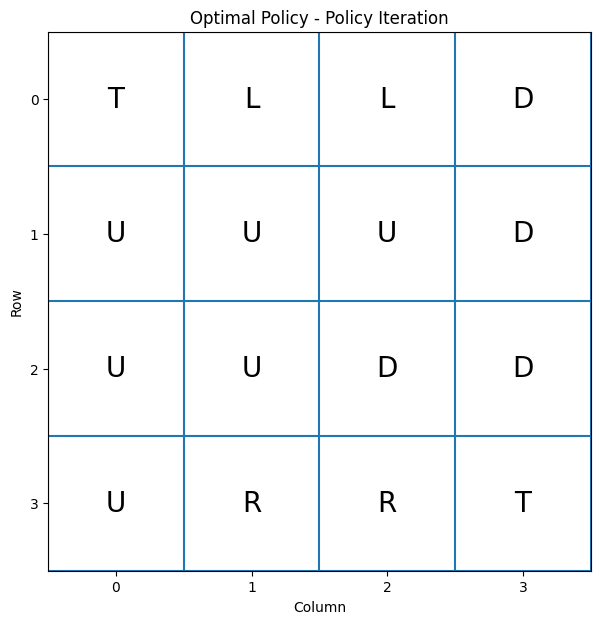

In [10]:
## **Visualize Optimal Policy**

plt.figure(figsize=(7, 7))

# Draw grid
for i in range(grid_size + 1):
    plt.axhline(i - 0.5)
    plt.axvline(i - 0.5)

# Display actions
for row in range(grid_size):

    for col in range(grid_size):

        state = (row, col)

        if state in terminal_states:
            text = "T"
        else:
            text = policy[state]

        plt.text(
            col,
            row,
            text,
            ha="center",
            va="center",
            fontsize=20
        )

plt.xlim(-0.5, grid_size - 0.5)
plt.ylim(grid_size - 0.5, -0.5)

plt.xticks(range(grid_size))
plt.yticks(range(grid_size))

plt.title("Optimal Policy - Policy Iteration")
plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

## **Visualize Value Function**

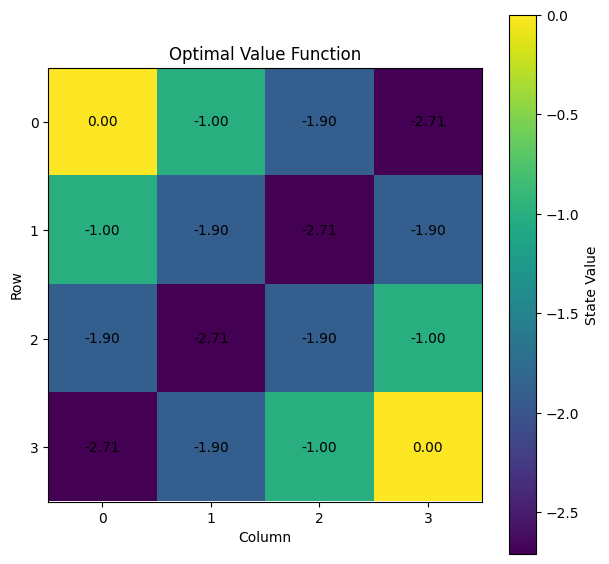

In [11]:
## **Visualize Optimal Value Function**

value_grid = np.zeros(
    (grid_size, grid_size)
)

for row in range(grid_size):

    for col in range(grid_size):

        value_grid[row, col] = V[(row, col)]

plt.figure(figsize=(7, 7))

plt.imshow(value_grid)

plt.colorbar(label="State Value")

plt.xticks(range(grid_size))
plt.yticks(range(grid_size))

plt.title("Optimal Value Function")

for row in range(grid_size):

    for col in range(grid_size):

        state = (row, col)

        plt.text(
            col,
            row,
            f"{V[state]:.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

## **Observation**

1. A 4 × 4 Grid World environment was successfully created.

2. An initial policy was assigned to all non-terminal states.

3. Policy Evaluation calculated the value function for the current policy.

4. Policy Improvement selected better actions based on their expected returns.

5. The evaluation and improvement steps were repeated until the policy became stable.

6. The final stable policy represents the optimal policy for the defined Grid World.

7. The value function shows the expected return associated with each state under the optimal policy.

## **Conclusion**

Policy Iteration was successfully implemented for a Grid World environment.

The algorithm repeatedly performed policy evaluation and policy improvement until a stable policy was obtained.

The experiment demonstrated how Dynamic Programming can be used to find an optimal policy when the environment model is known.